# Superstore Sales & Profitability Analysis

## 1. Data Understanding

In this section, I will explore the Superstore dataset to understand its structure, size, columns, data types, and basic statistics before starting the data cleaning and analysis process.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Dataset

I will now load the Superstore dataset into a Pandas DataFrame so that I can explore and analyze the data.

In [6]:
# Load the dataset

df = pd.read_csv("../data/Superstore.csv", encoding="latin1")

### Checking the Size of the Dataset

I will check the number of rows and columns in the dataset to understand its overall size.

In [7]:
# Check the number of rows and columns

df.shape

(9994, 21)

### Checking the Column Names

I will check all the column names to understand what information is available in the dataset.

In [8]:
# Display all column names

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Checking Data Types and Missing Values

I will check the data types of each column and identify whether there are any missing values in the dataset.

In [9]:
# Check the structure and data types of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### Checking Basic Statistics

I will use descriptive statistics to understand the numerical columns and their basic distribution in the dataset.

In [10]:
# Display basic statistics for numerical columns

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Checking Basic Statistics

I will use descriptive statistics to get an overview of the numerical columns and understand their distributions.

In [11]:
# Display basic statistics for numerical columns

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 2. Data Quality Check

### Checking for Missing Values

I will check each column for missing values to understand whether any data needs to be handled before performing the analysis.

In [12]:
# Check for missing values

df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Missing Value Percentage

I will calculate the percentage of missing values in each column to understand how significant the missing data is.

In [13]:
# Calculate missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Row ID           0.0
Postal Code      0.0
Discount         0.0
Quantity         0.0
Sales            0.0
Product Name     0.0
Sub-Category     0.0
Category         0.0
Product ID       0.0
Region           0.0
State            0.0
Order ID         0.0
City             0.0
Country          0.0
Segment          0.0
Customer Name    0.0
Customer ID      0.0
Ship Mode        0.0
Ship Date        0.0
Order Date       0.0
Profit           0.0
dtype: float64

### Checking for Duplicate Records

I will check whether the dataset contains any duplicate rows that could affect the accuracy of the analysis.

In [14]:
# Check for duplicate rows

df.duplicated().sum()

np.int64(0)

### Checking Duplicate Order IDs

I will check whether any Order IDs appear more than once in the dataset. This will help me understand whether an order can contain multiple products or records.

In [15]:
# Check the number of unique and duplicate Order IDs

print("Total Order IDs:", df["Order ID"].count())
print("Unique Order IDs:", df["Order ID"].nunique())

Total Order IDs: 9994
Unique Order IDs: 5009


In [16]:
# Find the number of Order IDs that appear more than once

duplicate_order_ids = df["Order ID"].value_counts()

duplicate_order_ids[duplicate_order_ids > 1].head(10)

Order ID
CA-2017-100111    14
CA-2017-157987    12
CA-2016-165330    11
US-2016-108504    11
CA-2015-131338    10
CA-2016-105732    10
US-2015-126977    10
US-2016-114013     9
CA-2014-106439     9
CA-2016-145177     9
Name: count, dtype: int64

### Checking Data Types

I will check the data types of the columns to make sure they are suitable for analysis and identify any columns that need to be converted.

In [17]:
# Display the data type of each column

df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

### Converting Date Columns

I will convert the Order Date and Ship Date columns into datetime format so that I can perform time-based analysis later.

In [18]:
# Convert date columns to datetime

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [19]:
# Check the data types after conversion

df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

### Checking Unique Values

I will check the number of unique values in each column to understand the different categories and groups available in the dataset.

In [20]:
# Check the number of unique values in each column

df.nunique().sort_values()

Country             1
Category            3
Segment             3
Region              4
Ship Mode           4
Discount           12
Quantity           14
Sub-Category       17
State              49
City              531
Postal Code       631
Customer ID       793
Customer Name     793
Order Date       1237
Ship Date        1334
Product Name     1850
Product ID       1862
Order ID         5009
Sales            5825
Profit           7287
Row ID           9994
dtype: int64

In [21]:
# Display unique values of important categorical columns

categorical_columns = [
    "Ship Mode",
    "Segment",
    "Category",
    "Sub-Category",
    "Region"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Ship Mode:
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segment:
['Consumer' 'Corporate' 'Home Office']

Category:
['Furniture' 'Office Supplies' 'Technology']

Sub-Category:
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']

Region:
['South' 'West' 'Central' 'East']


## 3. Data Cleaning

### Checking Numerical Values

I will check the numerical columns for unusual or invalid values before performing any cleaning.

In [22]:
# Check the basic range of important numerical columns

numerical_columns = ["Sales", "Quantity", "Discount", "Profit"]

df[numerical_columns].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [23]:
# Check for negative values in numerical columns

for column in numerical_columns:
    print(f"{column}: {(df[column] < 0).sum()} negative values")

Sales: 0 negative values
Quantity: 0 negative values
Discount: 0 negative values
Profit: 1871 negative values


### Checking for Outliers

I will use box plots to identify potential outliers in the main numerical columns. I will investigate these values before deciding whether they should be removed or retained.

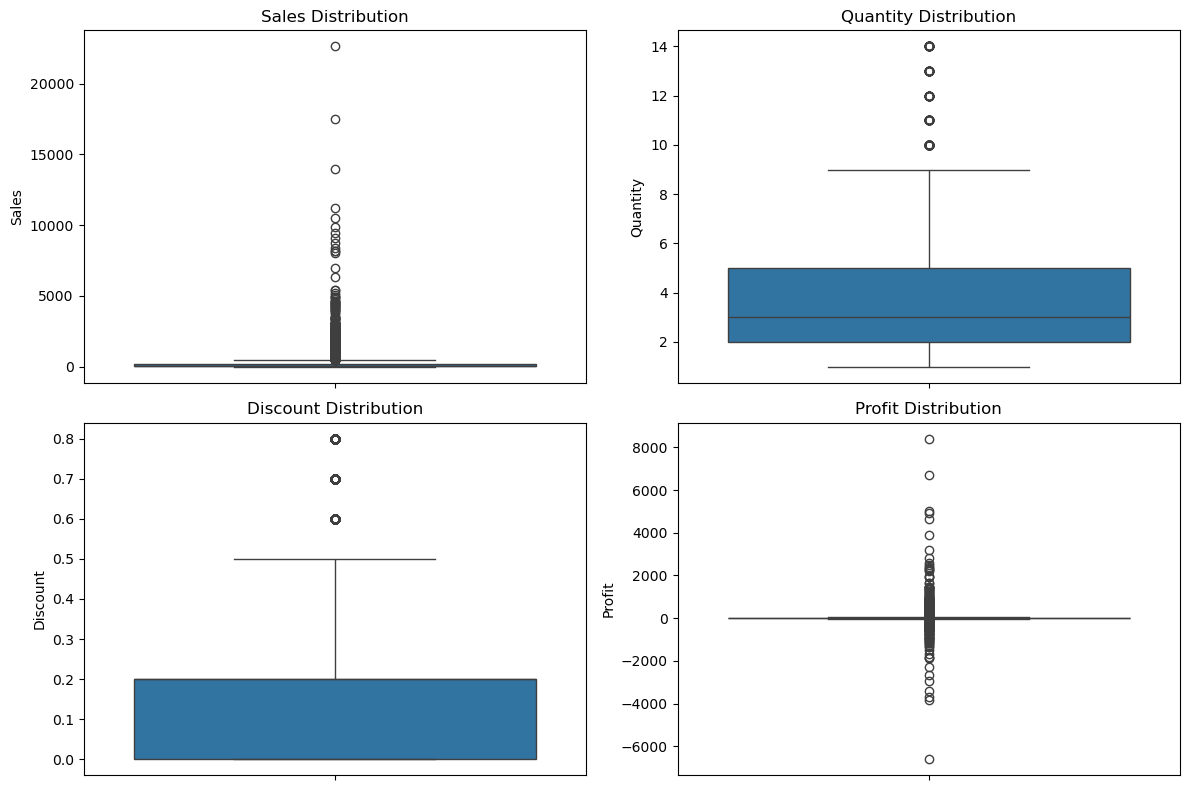

In [24]:
# Check for potential outliers

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flatten(), numerical_columns):
    sns.boxplot(y=df[column], ax=ax)
    ax.set_title(f"{column} Distribution")

plt.tight_layout()
plt.show()

### Inspecting Extreme Values

The box plots show potential outliers in some numerical columns. I will inspect the extreme values to determine whether they are valid observations or possible data-quality issues.

In [25]:
# Display the highest values in the main numerical columns

for column in numerical_columns:
    print(f"\nTop 10 values in {column}:")
    print(df[column].nlargest(10).values)


Top 10 values in Sales:
[22638.48  17499.95  13999.96  11199.968 10499.97   9892.74   9449.95
  9099.93   8749.95   8399.976]

Top 10 values in Quantity:
[14 14 14 14 14 14 14 14 14 14]

Top 10 values in Discount:
[0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8]

Top 10 values in Profit:
[8399.976  6719.9808 5039.9856 4946.37   4630.4755 3919.9888 3177.475
 2799.984  2591.9568 2504.2216]


In [26]:
# Display the lowest values in the main numerical columns

for column in numerical_columns:
    print(f"\nBottom 10 values in {column}:")
    print(df[column].nsmallest(10).values)


Bottom 10 values in Sales:
[0.444 0.556 0.836 0.852 0.876 0.898 0.984 0.99  1.044 1.08 ]

Bottom 10 values in Quantity:
[1 1 1 1 1 1 1 1 1 1]

Bottom 10 values in Discount:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Bottom 10 values in Profit:
[-6599.978  -3839.9904 -3701.8928 -3399.98   -2929.4845 -2639.9912
 -2287.782  -1862.3124 -1850.9464 -1811.0784]


### Checking Data Consistency

I will check the numerical columns for values that may be inconsistent with the business context of the dataset.

In [27]:
# Check whether Quantity contains zero or negative values

print("Zero quantities:", (df["Quantity"] == 0).sum())
print("Negative quantities:", (df["Quantity"] < 0).sum())

Zero quantities: 0
Negative quantities: 0


In [28]:
# Check the range of discount values

print("Minimum discount:", df["Discount"].min())
print("Maximum discount:", df["Discount"].max())

Minimum discount: 0.0
Maximum discount: 0.8


In [29]:
# Check whether Sales contains zero or negative values

print("Zero sales:", (df["Sales"] == 0).sum())
print("Negative sales:", (df["Sales"] < 0).sum())

Zero sales: 0
Negative sales: 0


In [ ]:
# Check the number of profitable and loss-making transactions

print("Profitable transactions:", (df["Profit"] > 0).sum())
print("Loss-making transactions:", (df["Profit"] < 0).sum())
print("Zero-profit transactions:", (df["Profit"] == 0).sum())

Profitable transactions: 8058
Loss-making transactions: 1871
Zero-profit transactions: 65


### Creating a Clean Dataset

I will create a copy of the original dataset so that the raw data remains unchanged while I perform the cleaning and transformation steps.

In [31]:
# Create a copy of the original dataset

df_clean = df.copy()

In [32]:
# Check the shape of the cleaned dataset

df_clean.shape

(9994, 21)

In [33]:
# Check missing values in the cleaned dataset

df_clean.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [34]:
# Check duplicate rows

df_clean.duplicated().sum()

np.int64(0)

## 4. Feature Engineering

### Creating Date-Based Features

I will create additional date-based columns from the Order Date column to make it easier to analyze sales and profit trends over time.

In [35]:
# Create date-based features

df_clean["Order Year"] = df_clean["Order Date"].dt.year
df_clean["Order Month"] = df_clean["Order Date"].dt.month
df_clean["Order Month Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Order Year-Month"] = df_clean["Order Date"].dt.to_period("M")

### Calculating Shipping Duration

I will calculate the number of days taken between the order date and the ship date to analyze shipping performance.

In [38]:
# Calculate shipping duration in days

df_clean["Shipping Days"] = (
    df_clean["Ship Date"] - df_clean["Order Date"]
).dt.days

In [37]:
# View shipping duration statistics

df_clean["Shipping Days"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

### Calculating Profit Margin

I will calculate the profit margin to understand profitability relative to sales.

In [39]:
# Calculate profit margin

df_clean["Profit Margin"] = (
    df_clean["Profit"] / df_clean["Sales"]
) * 100

In [40]:
# View profit margin statistics

df_clean["Profit Margin"].describe()

count    9994.000000
mean       12.031393
std        46.675435
min      -275.000000
25%         7.500000
50%        27.000000
75%        36.250000
max        50.000000
Name: Profit Margin, dtype: float64

### Verifying the New Features

I will check the newly created columns and a few sample records to make sure the feature engineering was performed correctly.

In [41]:
# Check the new columns

df_clean[
    [
        "Order Date",
        "Ship Date",
        "Order Year",
        "Order Month",
        "Order Month Name",
        "Order Year-Month",
        "Shipping Days",
        "Profit Margin"
    ]
].head()

,Order Date,Ship Date,Order Year,Order Month,Order Month Name,Order Year-Month,Shipping Days,Profit Margin
0,2016-11-08,2016-11-11,2016,11,November,2016-11,3,16.00
1,2016-11-08,2016-11-11,2016,11,November,2016-11,3,30.00
2,2016-06-12,2016-06-16,2016,6,June,2016-06,4,47.00
3,2015-10-11,2015-10-18,2015,10,October,2015-10,7,-40.00
4,2015-10-11,2015-10-18,2015,10,October,2015-10,7,11.25


In [42]:
# Display all columns after feature engineering

df_clean.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year',
       'Order Month', 'Order Month Name', 'Order Year-Month', 'Shipping Days',
       'Profit Margin'],
      dtype='object')

In [43]:
# Check the newly created features for missing and infinite values

features = [
    "Shipping Days",
    "Profit Margin"
]

print("Missing values:")
print(df_clean[features].isnull().sum())

print("\nInfinite values:")
print(np.isinf(df_clean[features]).sum())

Missing values:
Shipping Days    0
Profit Margin    0
dtype: int64

Infinite values:
Shipping Days    0
Profit Margin    0
dtype: int64


### 5.1 Overall Business Performance

I will first calculate some basic business metrics to get an overall understanding of the dataset before analyzing individual categories, regions, customers, and time trends.

In [44]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()

overall_profit_margin = (total_profit / total_sales) * 100

total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()
total_products = df_clean["Product ID"].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)
print("Overall Profit Margin:", overall_profit_margin, "%")
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity Sold: 37873
Overall Profit Margin: 12.467217240315605 %
Total Orders: 5009
Total Customers: 793
Total Products: 1862


### 5.2 Sales and Profit by Category

I will compare sales and profit across different product categories to understand which categories contribute more to revenue and profitability.

In [45]:
category_summary = df_clean.groupby("Category")[["Sales", "Profit"]].sum()

category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


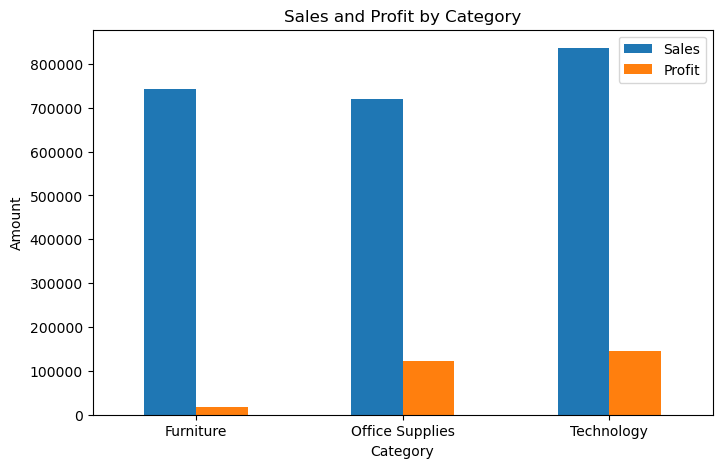

In [46]:
category_summary.plot(kind="bar", figsize=(8, 5))

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.show()

### 5.3 Sales and Profit by Sub-Category

I will analyze sales and profit at the sub-category level to identify the product types that contribute the most to sales and profitability.

In [47]:
subcategory_summary = df_clean.groupby("Sub-Category")[["Sales", "Profit"]].sum()

subcategory_summary.sort_values("Sales", ascending=False)

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


In [48]:
subcategory_summary.sort_values("Profit", ascending=False)

,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


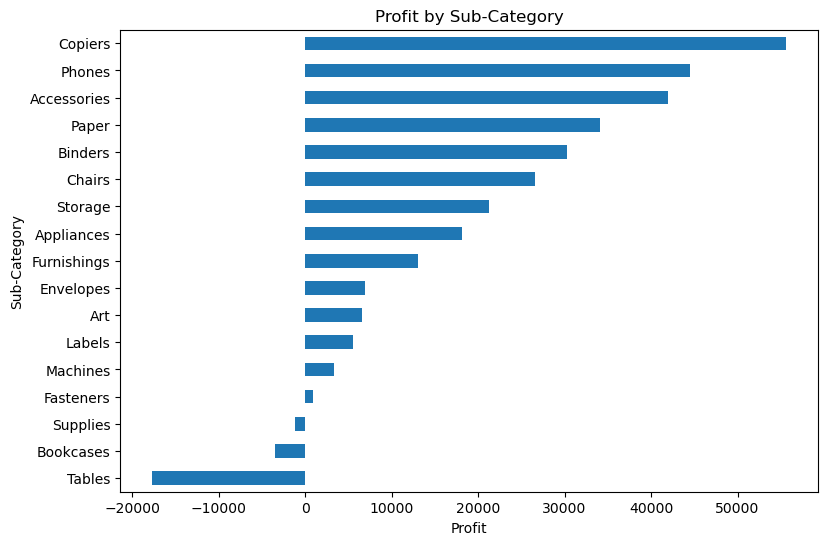

In [49]:
subcategory_summary.sort_values("Profit").plot(
    kind="barh",
    y="Profit",
    figsize=(9, 6),
    legend=False
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.show()

### 5.4 Sales and Profit by Region

I will compare sales and profit across different regions to understand how business performance varies geographically.

In [50]:
region_summary = df_clean.groupby("Region")[["Sales", "Profit"]].sum()

region_summary

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [51]:
region_summary.sort_values("Sales", ascending=False)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [52]:
region_summary.sort_values("Profit", ascending=False)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


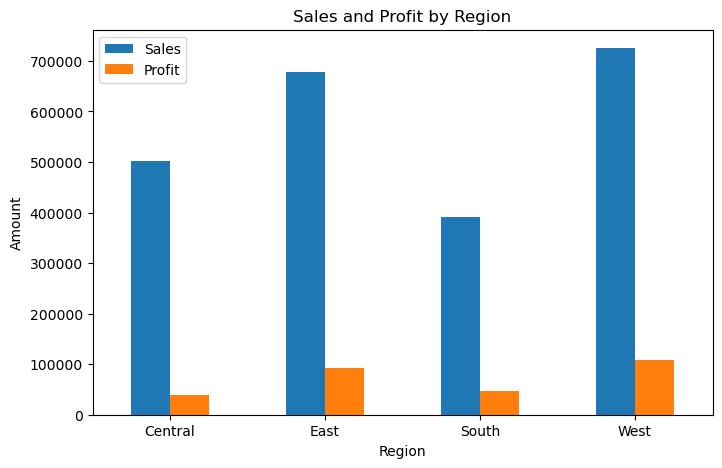

In [53]:
region_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.show()

### 5.5 Sales and Profit by Customer Segment

I will compare sales and profit across different customer segments to understand how each segment contributes to overall business performance.

In [54]:
segment_summary = df_clean.groupby("Segment")[["Sales", "Profit"]].sum()

segment_summary

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [55]:
segment_summary.sort_values("Sales", ascending=False)

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [56]:
segment_summary.sort_values("Profit", ascending=False)

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


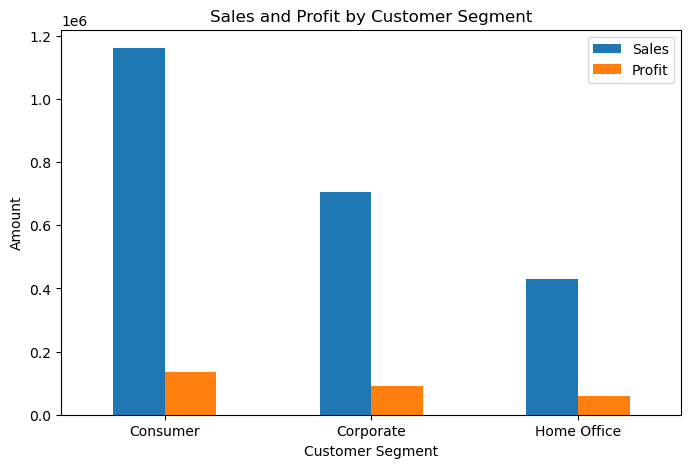

In [57]:
segment_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.show()

### 5.6 Sales and Profit Over Time

I will analyze sales and profit over time to identify overall trends and changes in business performance.

In [58]:
yearly_summary = df_clean.groupby("Order Year")[["Sales", "Profit"]].sum()

yearly_summary

,Sales,Profit
Order Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


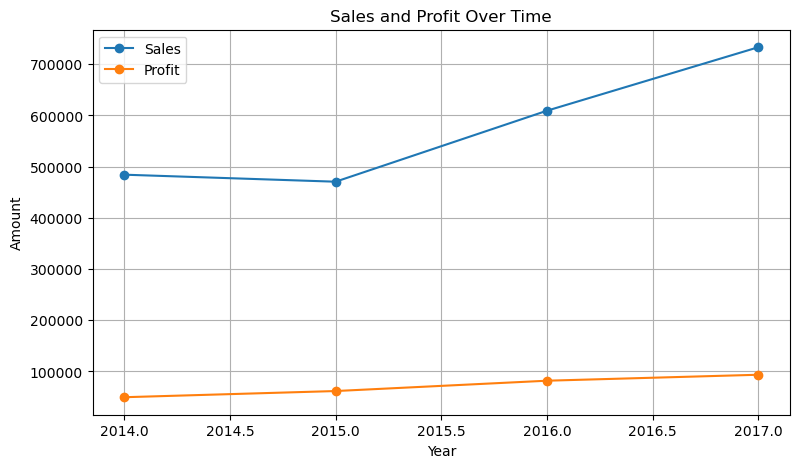

In [59]:
yearly_summary.plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Sales and Profit Over Time")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend(["Sales", "Profit"])
plt.grid(True)
plt.show()

In [60]:
monthly_summary = df_clean.groupby("Order Year-Month")[["Sales", "Profit"]].sum()

monthly_summary.head()

,Sales,Profit
Order Year-Month,,
2014-01,14236.895,2450.1907
2014-02,4519.892,862.3084
2014-03,55691.009,498.7299
2014-04,28295.345,3488.8352
2014-05,23648.287,2738.7096


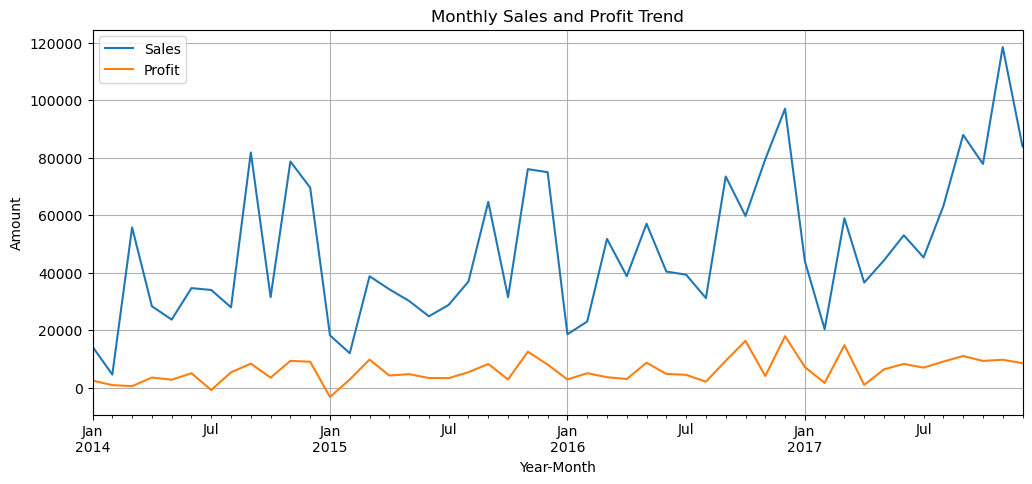

In [61]:
monthly_summary.plot(
    kind="line",
    figsize=(12, 5)
)

plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Amount")
plt.legend(["Sales", "Profit"])
plt.grid(True)
plt.show()

### 5.7 Discount vs. Profitability

I will analyze the relationship between discount and profit to understand how different discount levels are associated with profitability.

In [73]:
discount_summary = df_clean.groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
)

discount_summary

,Sales,Profit,Orders
Discount,,,
0.00,1.087908e+06,320987.6032,2644
0.10,5.436935e+04,9029.1770,89
0.15,2.755852e+04,1418.9915,51
0.20,7.645944e+05,90337.3060,2407
0.30,1.032267e+05,-10369.2774,211
0.32,1.449346e+04,-2391.1377,27
0.40,1.164178e+05,-23057.0504,185
0.45,5.484974e+03,-2493.1111,10
0.50,5.891854e+04,-20506.4281,64


In [65]:
df_clean.groupby("Discount")["Profit"].mean().sort_index()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

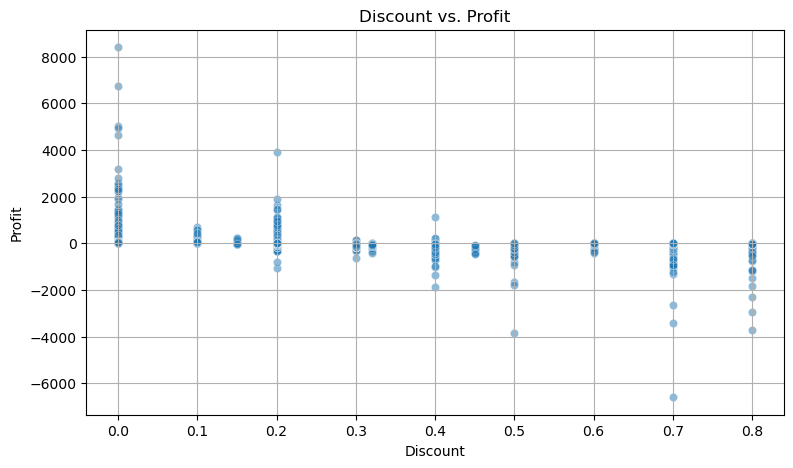

In [75]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_clean,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.title("Discount vs. Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

### 5.8 Loss-Making Products

I will identify products that are generating losses to understand which products may require further investigation.

In [76]:
loss_making_products = (
    df_clean.groupby(["Product ID", "Product Name"])["Profit"]
    .sum()
    .sort_values()
)

loss_making_products.head(10)

Product ID       Product Name                                                     
TEC-MA-10000418  Cubify CubeX 3D Printer Double Head Print                           -8879.9704
TEC-MA-10000822  Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
TEC-MA-10004125  Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
FUR-TA-10000198  Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
FUR-TA-10001889  Bush Advantage Collection Racetrack Conference Table                -1934.3976
OFF-BI-10004995  GBC DocuBind P400 Electric Binding System                           -1878.1662
TEC-MA-10002412  Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
OFF-SU-10002881  Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
FUR-TA-10001950  Balt Solid Wood Round Tables                                        -1201.0581
FUR-TA-10004289  BoxOffice By Design Rectangular and 

In [77]:
loss_making_products = loss_making_products[loss_making_products < 0]

loss_making_products.head(10)

Product ID       Product Name                                                     
TEC-MA-10000418  Cubify CubeX 3D Printer Double Head Print                           -8879.9704
TEC-MA-10000822  Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
TEC-MA-10004125  Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
FUR-TA-10000198  Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
FUR-TA-10001889  Bush Advantage Collection Racetrack Conference Table                -1934.3976
OFF-BI-10004995  GBC DocuBind P400 Electric Binding System                           -1878.1662
TEC-MA-10002412  Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
OFF-SU-10002881  Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
FUR-TA-10001950  Balt Solid Wood Round Tables                                        -1201.0581
FUR-TA-10004289  BoxOffice By Design Rectangular and 

In [78]:
total_loss_making = len(loss_making_products)

print("Number of loss-making products:", total_loss_making)

Number of loss-making products: 306


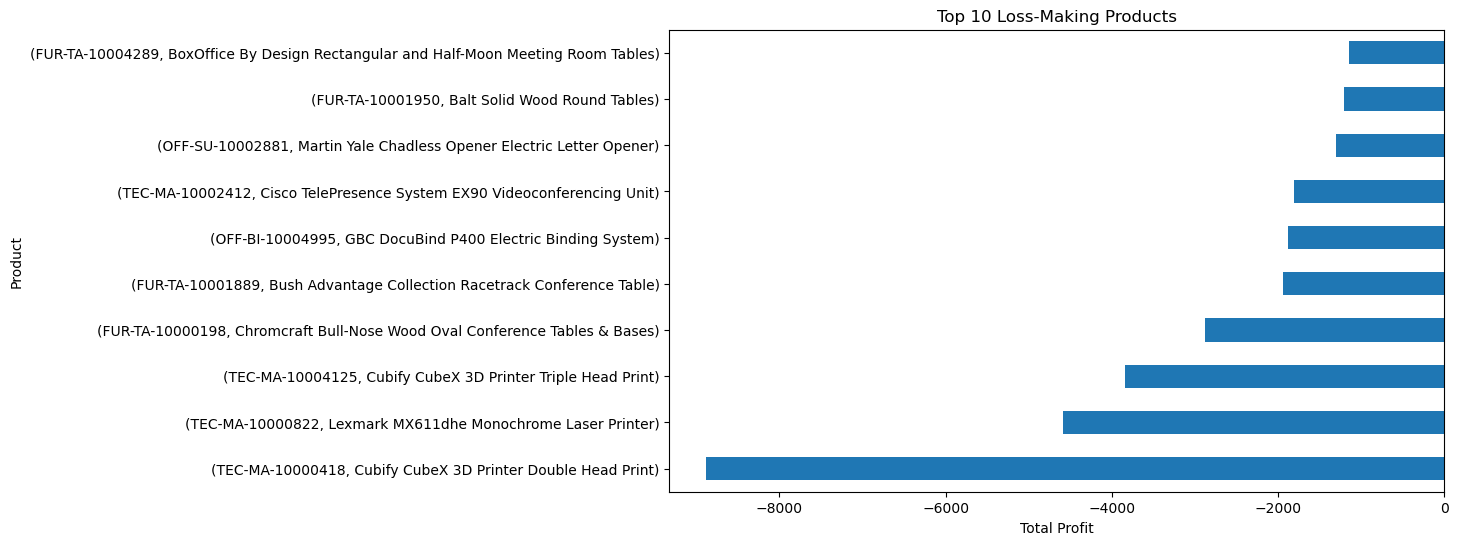

In [79]:
loss_making_products.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Profit")
plt.ylabel("Product")
plt.show()

In [80]:
profitable_products = (
    df_clean.groupby(["Product ID", "Product Name"])["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profitable_products.head(10)

Product ID       Product Name                                                               
TEC-CO-10004722  Canon imageCLASS 2200 Advanced Copier                                          25199.9280
OFF-BI-10003527  Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
TEC-CO-10001449  Hewlett Packard LaserJet 3310 Copier                                            6983.8836
TEC-CO-10003763  Canon PC1060 Personal Laser Copier                                              4570.9347
TEC-MA-10001127  HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
TEC-MA-10003979  Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
TEC-MA-10001047  3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
TEC-AC-10002049  Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
OFF-BI-10001120  Ibico EPK-21 Electric Binding Syst

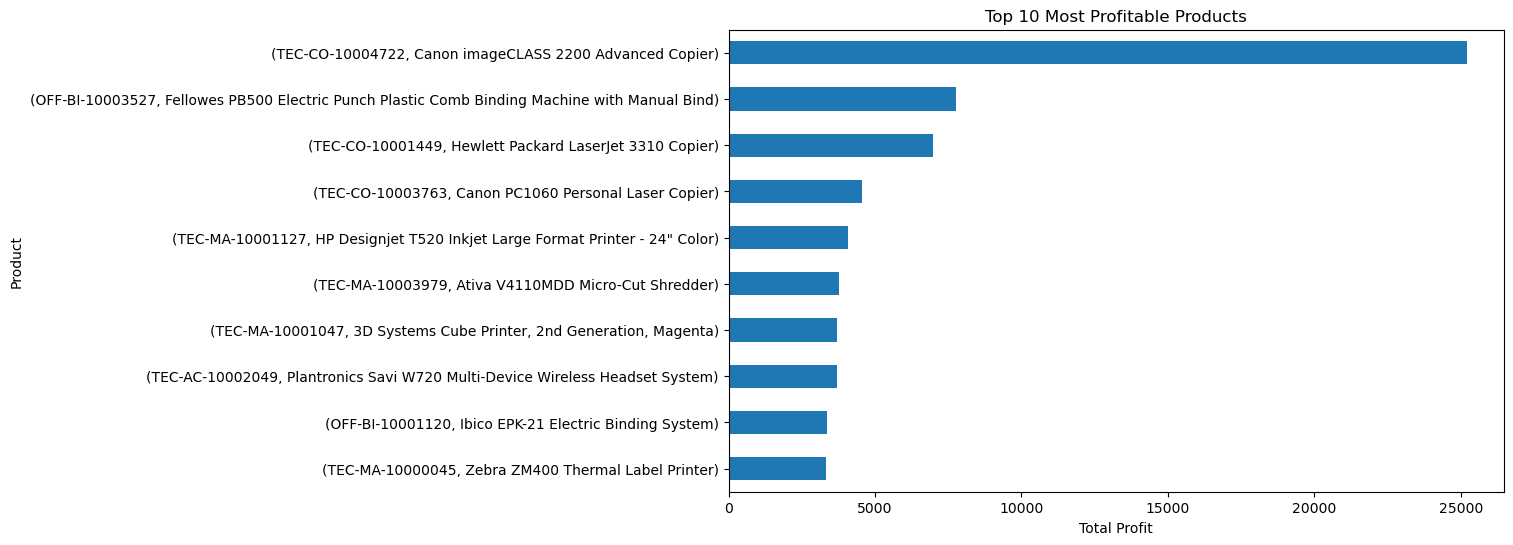

In [81]:
profitable_products.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Total Profit")
plt.ylabel("Product")
plt.show()

In [82]:
total_profit_from_products = profitable_products[profitable_products > 0].sum()
total_loss_from_products = loss_making_products.sum()

print("Total profit from profitable products:", total_profit_from_products)
print("Total loss from loss-making products:", total_loss_from_products)

Total profit from profitable products: 363489.03890000004
Total loss from loss-making products: -77092.01719999999


In [83]:
category_summary["Profit Margin (%)"] = (
    category_summary["Profit"] / category_summary["Sales"]
) * 100

category_summary.sort_values("Profit Margin (%)", ascending=False)

,Sales,Profit,Profit Margin (%)
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


In [84]:
segment_summary["Profit Margin (%)"] = (
    segment_summary["Profit"] / segment_summary["Sales"]
) * 100

segment_summary.sort_values("Profit Margin (%)", ascending=False)

,Sales,Profit,Profit Margin (%)
Segment,,,
Home Office,4.296531e+05,60298.6785,14.034269
Corporate,7.061464e+05,91979.1340,13.025506
Consumer,1.161401e+06,134119.2092,11.548050


### 5.9 Sales and Profit by Ship Mode

I will compare sales and profit across different shipping modes to understand how shipping methods are associated with overall business performance.

In [85]:
ship_mode_summary = df_clean.groupby("Ship Mode")[["Sales", "Profit"]].sum()

ship_mode_summary

,Sales,Profit
Ship Mode,,
First Class,3.514284e+05,48969.8399
Same Day,1.283631e+05,15891.7589
Second Class,4.591936e+05,57446.6354
Standard Class,1.358216e+06,164088.7875


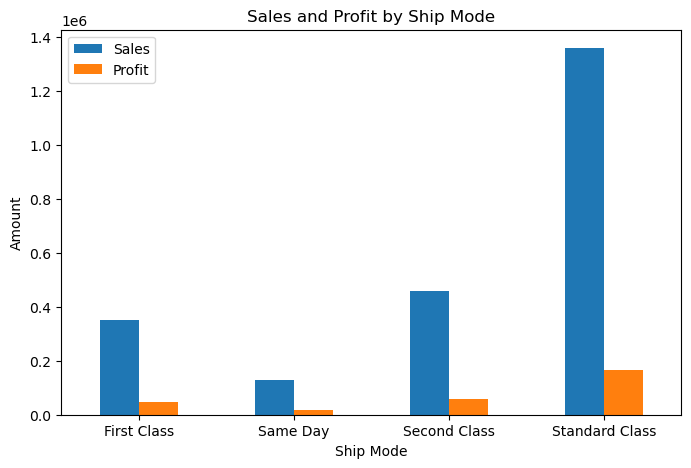

In [86]:
ship_mode_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales and Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.show()

In [87]:
df_clean["Shipping Days"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

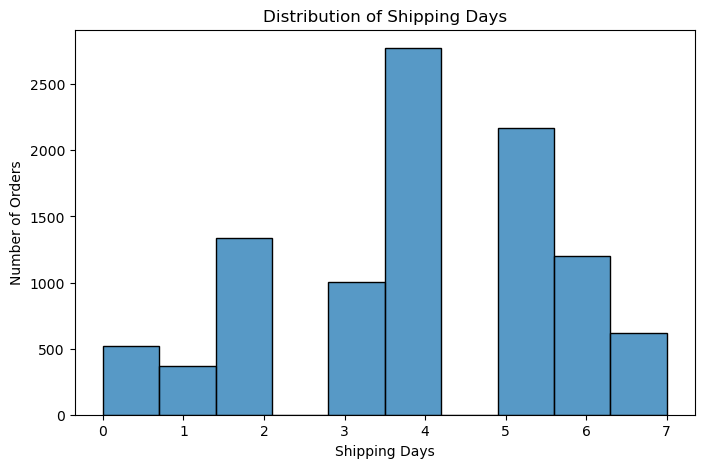

In [88]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="Shipping Days",
    bins=10
)

plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")
plt.show()

In [89]:
subcategory_summary["Profit Margin (%)"] = (
    subcategory_summary["Profit"] / subcategory_summary["Sales"]
) * 100

subcategory_summary.sort_values("Profit Margin (%)", ascending=False)

,Sales,Profit,Profit Margin (%)
Sub-Category,,,
Labels,12486.3120,5546.2540,44.418672
Paper,78479.2060,34053.5693,43.391837
Envelopes,16476.4020,6964.1767,42.267582
Copiers,149528.0300,55617.8249,37.195585
Fasteners,3024.2800,949.5182,31.396504
Accessories,167380.3180,41936.6357,25.054700
Art,27118.7920,6527.7870,24.071083
Appliances,107532.1610,18138.0054,16.867517
Binders,203412.7330,30221.7633,14.857361


### 5.10 Sales and Profit by State

I will analyze sales and profit across different states to identify geographic differences in business performance.

In [90]:
state_summary = df_clean.groupby("State")[["Sales", "Profit"]].sum()

state_summary.sort_values("Sales", ascending=False).head(10)

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486
Texas,170188.0458,-25729.3563
Washington,138641.2700,33402.6517
Pennsylvania,116511.9140,-15559.9603
Florida,89473.7080,-3399.3017
Illinois,80166.1010,-12607.8870
Ohio,78258.1360,-16971.3766
Michigan,76269.6140,24463.1876


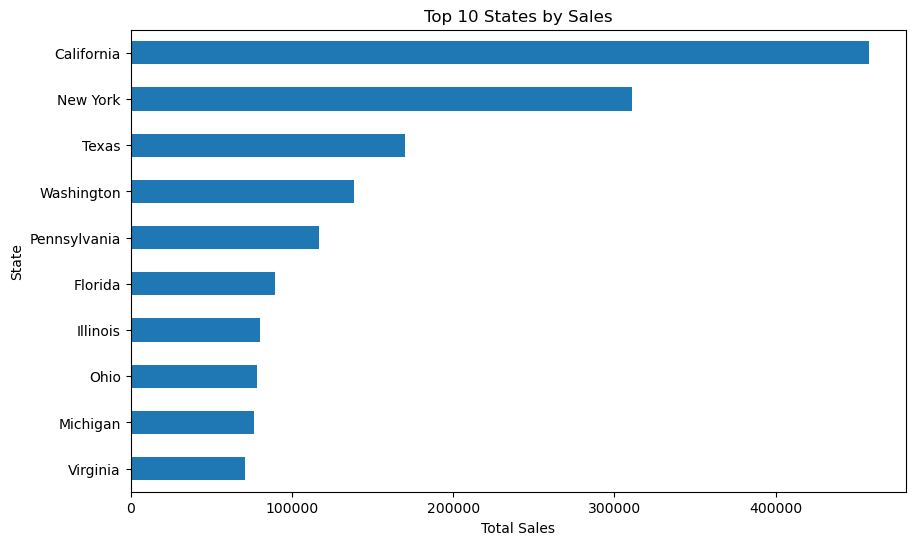

In [91]:
state_summary.sort_values("Sales", ascending=False).head(10).sort_values("Sales").plot(
    kind="barh",
    y="Sales",
    figsize=(10, 6),
    legend=False
)

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.show()

In [92]:
state_summary.sort_values("Profit", ascending=False).head(10)

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486
Washington,138641.2700,33402.6517
Michigan,76269.6140,24463.1876
Virginia,70636.7200,18597.9504
Indiana,53555.3600,18382.9363
Georgia,49095.8400,16250.0433
Kentucky,36591.7500,11199.6966
Minnesota,29863.1500,10823.1874


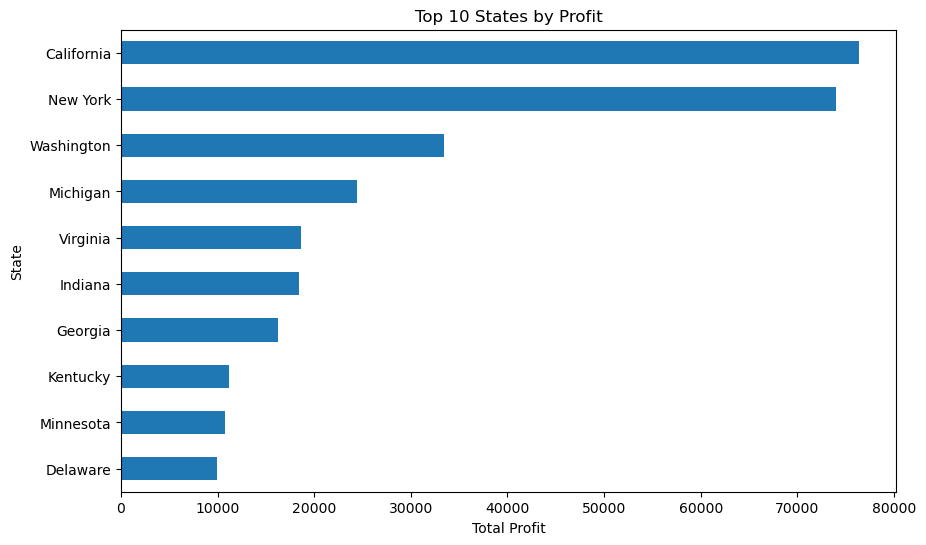

In [93]:
state_summary.sort_values("Profit", ascending=False).head(10).sort_values("Profit").plot(
    kind="barh",
    y="Profit",
    figsize=(10, 6),
    legend=False
)

plt.title("Top 10 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.show()

In [94]:
city_summary = df_clean.groupby("City")[["Sales", "Profit"]].sum()

city_summary.sort_values("Sales", ascending=False).head(10)

,Sales,Profit
City,,
New York City,256368.1610,62036.9837
Los Angeles,175851.3410,30440.7579
Seattle,119540.7420,29156.0967
San Francisco,112669.0920,17507.3854
Philadelphia,109077.0130,-13837.7674
Houston,64504.7604,-10153.5485
Chicago,48539.5410,-6654.5688
San Diego,47521.0290,6377.1960
Jacksonville,44713.1830,-2323.8350


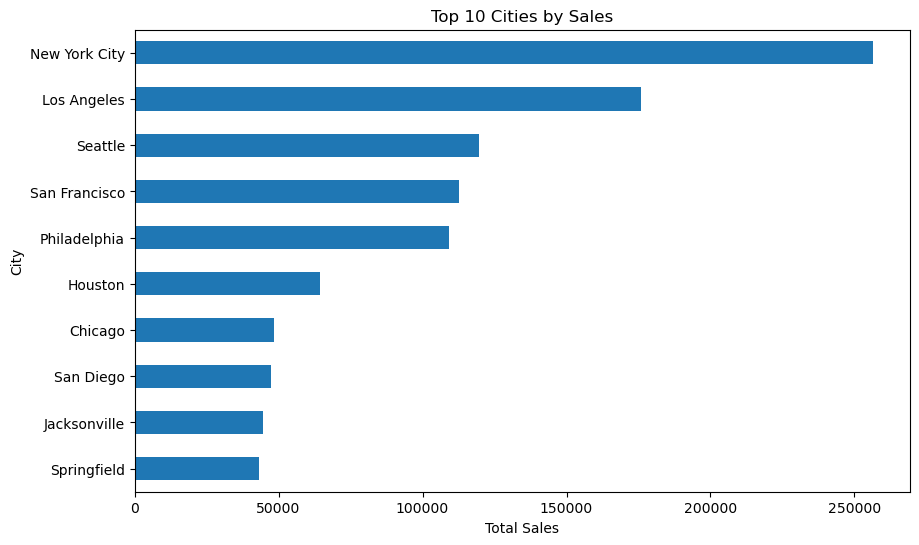

In [95]:
city_summary.sort_values("Sales", ascending=False).head(10).sort_values("Sales").plot(
    kind="barh",
    y="Sales",
    figsize=(10, 6),
    legend=False
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()

In [96]:
city_summary.sort_values("Profit", ascending=False).head(10)

,Sales,Profit
City,,
New York City,256368.161,62036.9837
Los Angeles,175851.341,30440.7579
Seattle,119540.742,29156.0967
San Francisco,112669.092,17507.3854
Detroit,42446.944,13181.7908
Lafayette,25036.200,10018.3876
Jackson,24963.858,7581.6828
Atlanta,17197.840,6993.6629
Minneapolis,16870.540,6824.5846


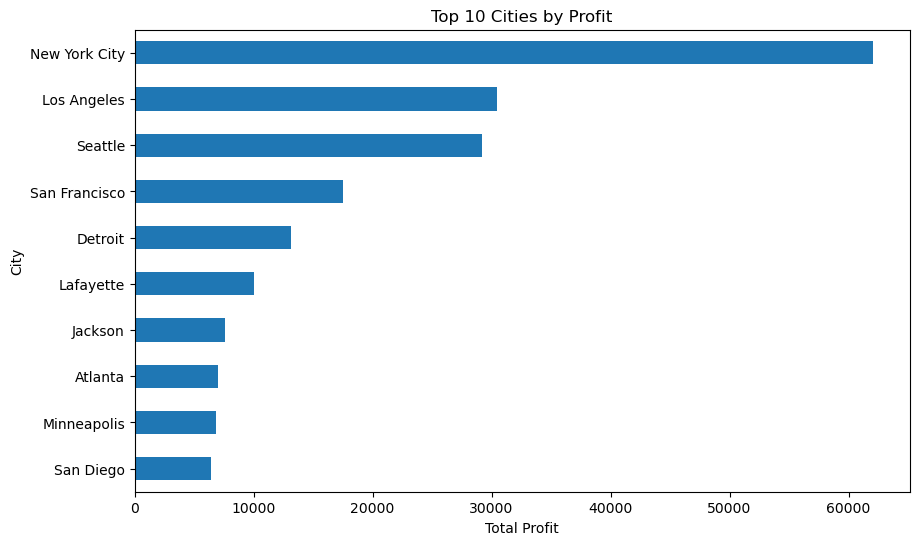

In [97]:
city_summary.sort_values("Profit", ascending=False).head(10).sort_values("Profit").plot(
    kind="barh",
    y="Profit",
    figsize=(10, 6),
    legend=False
)

plt.title("Top 10 Cities by Profit")
plt.xlabel("Total Profit")
plt.ylabel("City")
plt.show()

In [98]:
category_subcategory_summary = (
    df_clean.groupby(["Category", "Sub-Category"])[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

category_subcategory_summary.head(10)

Sales      Profit
Category        Sub-Category                        
Technology      Copiers       149528.030  55617.8249
                Phones        330007.054  44515.7306
                Accessories   167380.318  41936.6357
Office Supplies Paper          78479.206  34053.5693
                Binders       203412.733  30221.7633
Furniture       Chairs        328449.103  26590.1663
Office Supplies Storage       223843.608  21278.8264
                Appliances    107532.161  18138.0054
Furniture       Furnishings    91705.164  13059.1436
Office Supplies Envelopes      16476.402   6964.1767

In [99]:
year_category_summary = (
    df_clean.groupby(["Order Year", "Category"])[["Sales", "Profit"]]
    .sum()
)

year_category_summary

Sales      Profit
Order Year Category                                
2014       Furniture        157192.8531   5457.7255
           Office Supplies  151776.4120  22593.4161
           Technology       175278.2330  21492.8325
2015       Furniture        170518.2370   3015.2029
           Office Supplies  137233.4630  25099.5338
           Technology       162780.8090  33503.8670
2016       Furniture        198901.4360   6959.9531
           Office Supplies  183939.9820  35061.2292
           Technology       226364.1800  39773.9920
2017       Furniture        215387.2692   3018.3913
           Office Supplies  246097.1750  39736.6217
           Technology       271730.8110  50684.2566

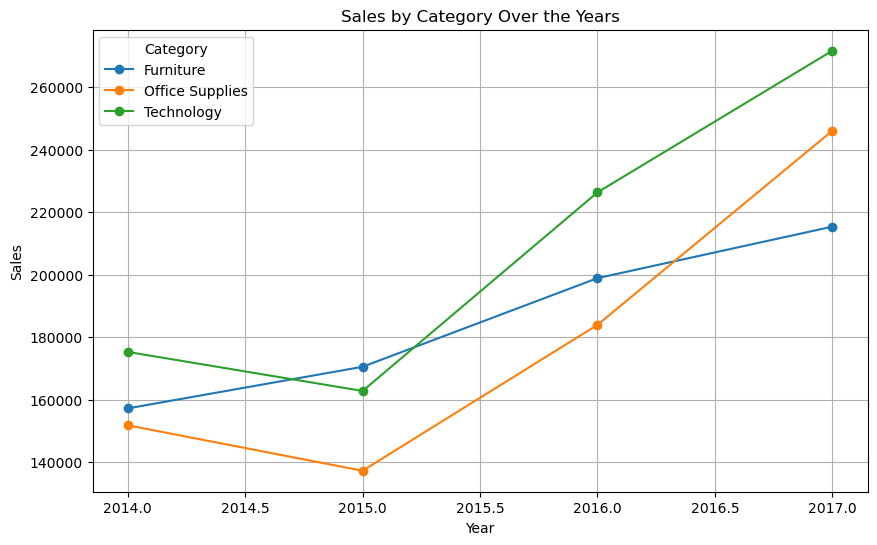

In [100]:
year_category_sales = (
    df_clean.groupby(["Order Year", "Category"])["Sales"]
    .sum()
    .unstack()
)

year_category_sales.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Sales by Category Over the Years")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend(title="Category")
plt.grid(True)
plt.show()

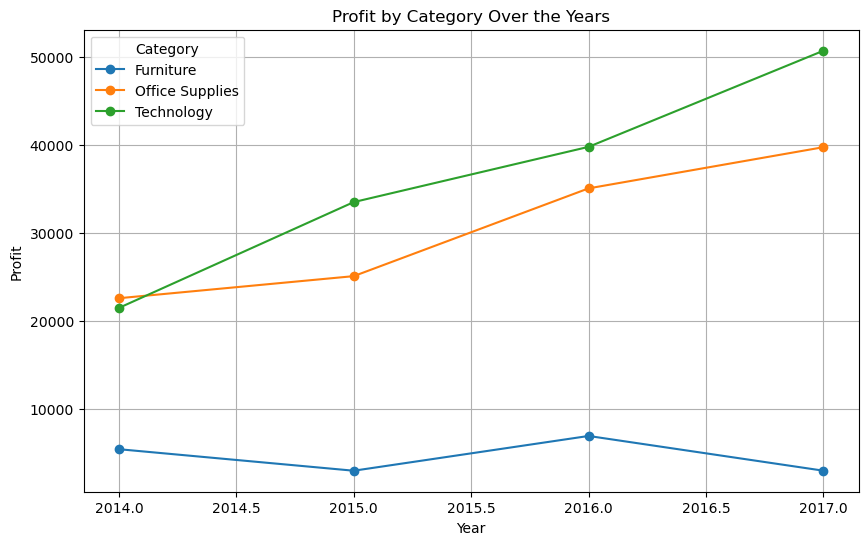

In [101]:
year_category_profit = (
    df_clean.groupby(["Order Year", "Category"])["Profit"]
    .sum()
    .unstack()
)

year_category_profit.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Profit by Category Over the Years")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.legend(title="Category")
plt.grid(True)
plt.show()

In [102]:
monthly_sales = (
    df_clean.groupby(["Order Year", "Order Month"])["Sales"]
    .sum()
    .unstack()
)

monthly_sales

Order Month,1,2,3,4,5,6,7,8,9,10,11,12
Order Year,,,,,,,,,,,,
2014,14236.8950,4519.8920,55691.0090,28295.3450,23648.2870,34595.1276,33946.393,27909.4685,81777.3508,31453.3930,78628.7167,69545.6205
2015,18174.0756,11951.4110,38726.2520,34195.2085,30131.6865,24797.2920,28765.325,36898.3322,64595.9180,31404.9235,75972.5635,74919.5212
2016,18542.4910,22978.8150,51715.8750,38750.0390,56987.7280,40344.5340,39261.963,31115.3743,73410.0249,59687.7450,79411.9658,96999.0430
2017,43971.3740,20301.1334,58872.3528,36521.5361,44261.1102,52981.7257,45264.416,63120.8880,87866.6520,77776.9232,118447.8250,83829.3188


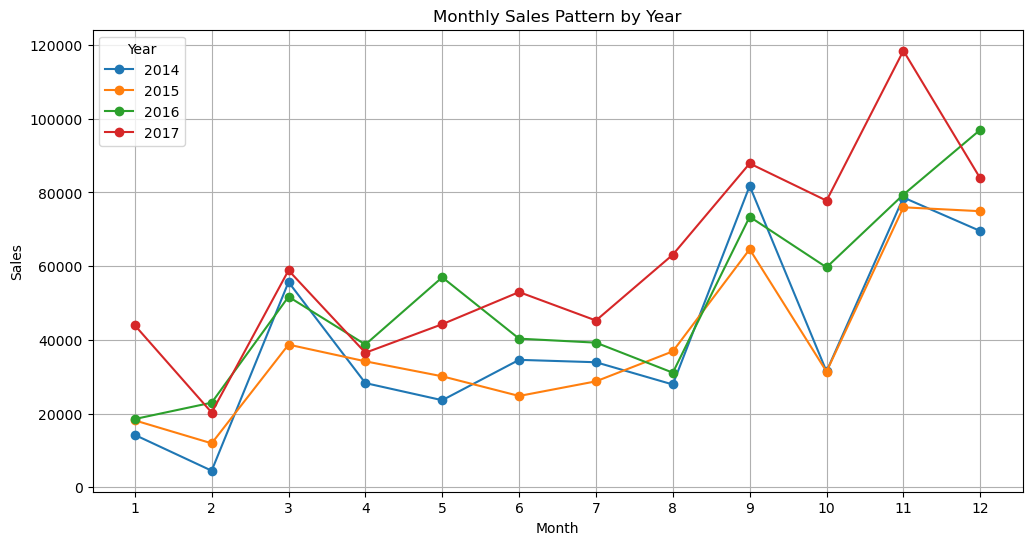

In [103]:
monthly_sales.T.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Monthly Sales Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.grid(True)
plt.show()

In [104]:
monthly_profit = (
    df_clean.groupby(["Order Year", "Order Month"])["Profit"]
    .sum()
    .unstack()
)

monthly_profit

Order Month,1,2,3,4,5,6,7,8,9,10,11,12
Order Year,,,,,,,,,,,,
2014,2450.1907,862.3084,498.7299,3488.8352,2738.7096,4976.5244,-841.4826,5318.1050,8328.0994,3448.2573,9292.1269,8983.5699
2015,-3281.0070,2813.8508,9732.0978,4187.4962,4667.8690,3335.5572,3288.6483,5355.8084,8209.1627,2817.3660,12474.7884,8016.9659
2016,2824.8233,5004.5795,3611.9680,2977.8149,8662.1464,4750.3781,4432.8779,2062.0693,9328.6576,16243.1425,4011.4075,17885.3093
2017,7140.4391,1613.8720,14751.8915,933.2900,6342.5828,8223.3357,6952.6212,9040.9557,10991.5556,9275.2755,9690.1037,8483.3468


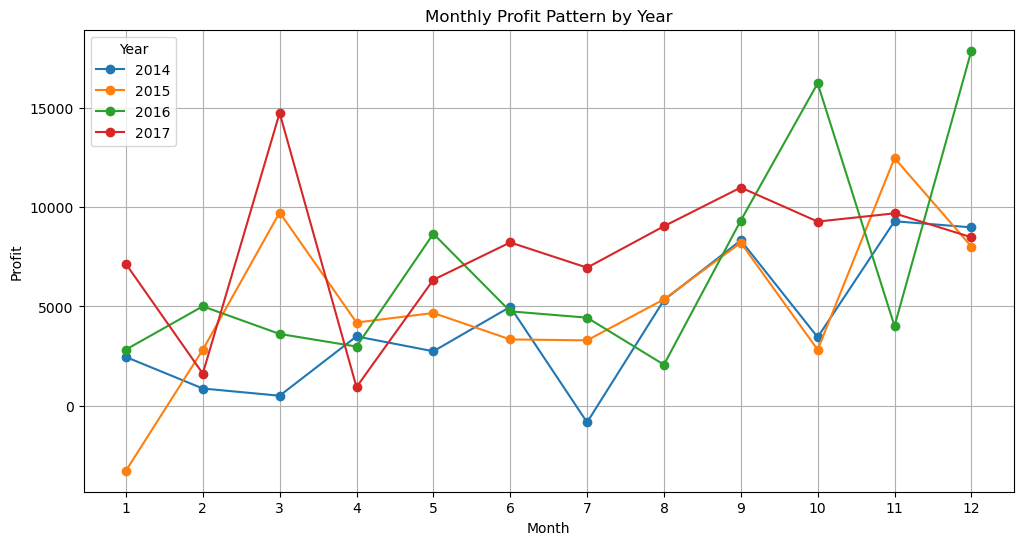

In [105]:
monthly_profit.T.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Monthly Profit Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.grid(True)
plt.show()

In [106]:
region_category_summary = (
    df_clean.groupby(["Region", "Category"])[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

region_category_summary

Sales      Profit
Region  Category                                
West    Office Supplies  220853.2490  52609.8490
East    Technology       264973.9810  47462.0351
West    Technology       251991.8320  44303.6496
East    Office Supplies  205516.0550  41014.5791
Central Technology       170416.3120  33697.4320
South   Technology       148771.9080  19991.8314
        Office Supplies  125651.3130  19986.3928
West    Furniture        252612.7435  11504.9503
Central Office Supplies  167026.4150   8879.9799
South   Furniture        117298.6840   6771.2061
East    Furniture        208291.2040   3046.1658
Central Furniture        163797.1638  -2871.0494

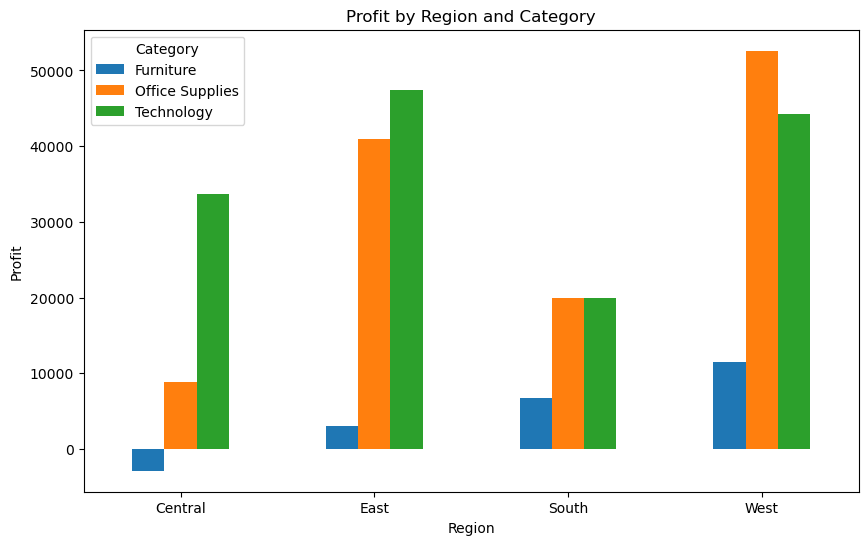

In [107]:
region_category_profit = (
    df_clean.groupby(["Region", "Category"])["Profit"]
    .sum()
    .unstack()
)

region_category_profit.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Profit by Region and Category")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.show()

In [108]:
discount_profitability = df_clean.groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
)

discount_profitability["Profit Margin (%)"] = (
    discount_profitability["Profit"] /
    discount_profitability["Sales"]
) * 100

discount_profitability.sort_index()

,Sales,Profit,Orders,Profit Margin (%)
Discount,,,,
0.00,1.087908e+06,320987.6032,2644,29.505019
0.10,5.436935e+04,9029.1770,89,16.607108
0.15,2.755852e+04,1418.9915,51,5.149012
0.20,7.645944e+05,90337.3060,2407,11.815063
0.30,1.032267e+05,-10369.2774,211,-10.045155
0.32,1.449346e+04,-2391.1377,27,-16.498047
0.40,1.164178e+05,-23057.0504,185,-19.805437
0.45,5.484974e+03,-2493.1111,10,-45.453472
0.50,5.891854e+04,-20506.4281,64,-34.804712


In [109]:
segment_category_summary = (
    df_clean.groupby(["Segment", "Category"])[["Sales", "Profit"]]
    .sum()
)

segment_category_summary

Sales      Profit
Segment     Category                                
Consumer    Furniture        391049.3120   6991.0786
            Office Supplies  363952.1360  56330.3210
            Technology       406399.8970  70797.8096
Corporate   Furniture        229019.7858   7584.8158
            Office Supplies  230676.4620  40227.3202
            Technology       246450.1190  44166.9980
Home Office Furniture        121930.6975   3875.3784
            Office Supplies  124418.4340  25933.1596
            Technology       183304.0170  30490.1405

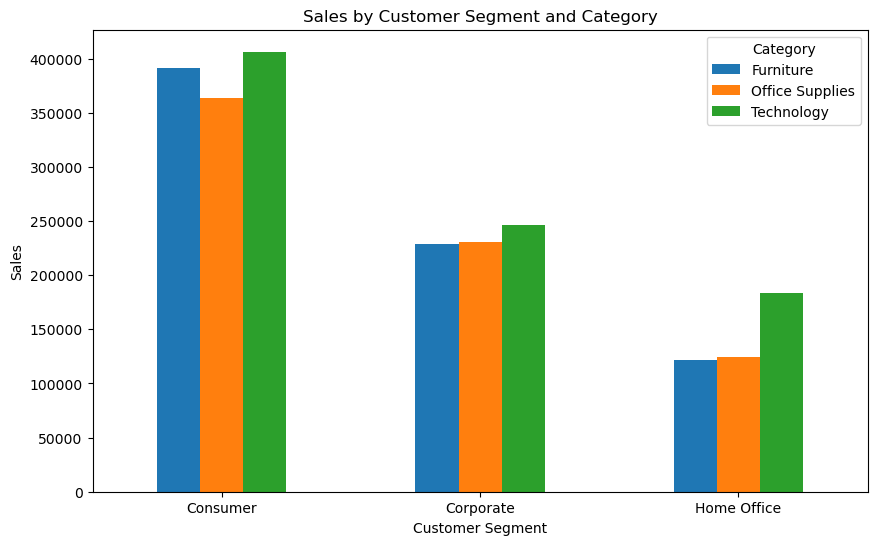

In [110]:
segment_category_sales = (
    df_clean.groupby(["Segment", "Category"])["Sales"]
    .sum()
    .unstack()
)

segment_category_sales.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales by Customer Segment and Category")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.show()

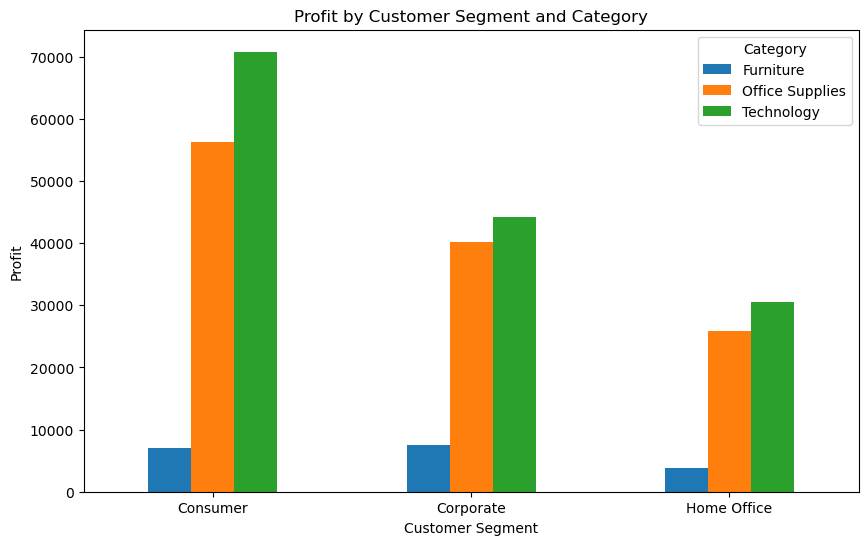

In [111]:
segment_category_profit = (
    df_clean.groupby(["Segment", "Category"])["Profit"]
    .sum()
    .unstack()
)

segment_category_profit.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Profit by Customer Segment and Category")
plt.xlabel("Customer Segment")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.show()

In [112]:
customer_summary = (
    df_clean.groupby(["Customer ID", "Customer Name"])[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

customer_summary.head(10)

,,Sales,Profit
Customer ID,Customer Name,,
SM-20320,Sean Miller,25043.050,-1980.7393
TC-20980,Tamara Chand,19052.218,8981.3239
RB-19360,Raymond Buch,15117.339,6976.0959
TA-21385,Tom Ashbrook,14595.620,4703.7883
AB-10105,Adrian Barton,14473.571,5444.8055
KL-16645,Ken Lonsdale,14175.229,806.8550
SC-20095,Sanjit Chand,14142.334,5757.4119
HL-15040,Hunter Lopez,12873.298,5622.4292
SE-20110,Sanjit Engle,12209.438,2650.6769


In [113]:
customer_summary.sort_values("Profit", ascending=False).head(10)

,,Sales,Profit
Customer ID,Customer Name,,
TC-20980,Tamara Chand,19052.218,8981.3239
RB-19360,Raymond Buch,15117.339,6976.0959
SC-20095,Sanjit Chand,14142.334,5757.4119
HL-15040,Hunter Lopez,12873.298,5622.4292
AB-10105,Adrian Barton,14473.571,5444.8055
TA-21385,Tom Ashbrook,14595.620,4703.7883
CM-12385,Christopher Martinez,8954.020,3899.8904
KD-16495,Keith Dawkins,8181.256,3038.6254
AR-10540,Andy Reiter,6608.448,2884.6208


In [114]:
customer_summary["Profit Margin (%)"] = (
    customer_summary["Profit"] / customer_summary["Sales"]
) * 100

customer_summary.sort_values("Profit Margin (%)", ascending=False).head(10)

,,Sales,Profit,Profit Margin (%)
Customer ID,Customer Name,,,
JC-15385,Jenna Caffey,1058.108,502.9244,47.530536
TC-20980,Tamara Chand,19052.218,8981.3239,47.140569
RB-19360,Raymond Buch,15117.339,6976.0959,46.146322
SR-20740,Steven Roelle,4345.886,1990.4244,45.800198
BO-11425,Bobby Odegard,130.830,59.4522,45.442330
HL-15040,Hunter Lopez,12873.298,5622.4292,43.675127
AR-10540,Andy Reiter,6608.448,2884.6208,43.650503
CM-12385,Christopher Martinez,8954.020,3899.8904,43.554631
IG-15085,Ivan Gibson,744.574,320.4982,43.044506


### 5.11 Correlation Analysis

I will analyze the correlation between the main numerical variables to understand how they are related to each other.

In [115]:
correlation_matrix = df_clean[
    ["Sales", "Quantity", "Discount", "Profit"]
].corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


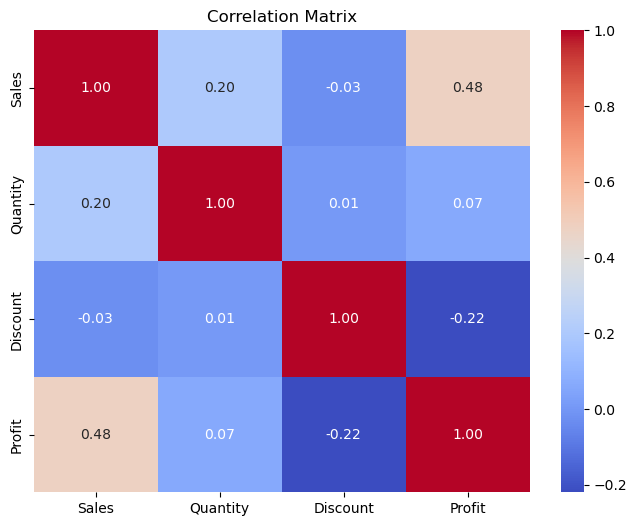

In [116]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [117]:
correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


In [118]:
discount_profit_correlation = df_clean["Discount"].corr(
    df_clean["Profit"]
)

print("Correlation between Discount and Profit:", discount_profit_correlation)

Correlation between Discount and Profit: -0.21948745637176784


In [119]:
outlier_summary = {}

for col in ["Sales", "Quantity", "Discount", "Profit"]:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ).sum()

    outlier_summary[col] = outliers

outlier_summary = pd.Series(
    outlier_summary,
    name="Outlier Count"
)

outlier_summary

Sales       1167
Quantity     170
Discount     856
Profit      1881
Name: Outlier Count, dtype: int64

In [120]:
statistical_summary = df_clean[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Profit",
        "Shipping Days",
        "Profit Margin"
    ]
].describe().T

statistical_summary

,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976
Shipping Days,9994.0,3.958175,1.747567,0.000,3.00000,4.0000,5.000,7.000
Profit Margin,9994.0,12.031393,46.675435,-275.000,7.50000,27.0000,36.250,50.000


### 6. Key Findings

Based on the analysis, I identified the main patterns in sales, profitability, discounts, products, regions, customer segments, and time trends.

The key findings from the analysis are:

In [121]:
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Sales: 2297200.86
Total Profit: 286397.02
Overall Profit Margin: 12.47 %
Total Orders: 5009
Total Customers: 793
Total Products: 1862


In [122]:
category_profit = category_summary["Profit"].sort_values(ascending=False)

print("Most profitable category:")
print(category_profit.head(1))

print("\nLowest-profit category:")
print(category_profit.tail(1))

Most profitable category:
Category
Technology    145454.9481
Name: Profit, dtype: float64

Lowest-profit category:
Category
Furniture    18451.2728
Name: Profit, dtype: float64


In [123]:
subcategory_profit = (
    df_clean.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Most profitable sub-category:")
print(subcategory_profit.head(1))

print("\nLeast profitable sub-category:")
print(subcategory_profit.tail(1))

Most profitable sub-category:
Sub-Category
Copiers    55617.8249
Name: Profit, dtype: float64

Least profitable sub-category:
Sub-Category
Tables   -17725.4811
Name: Profit, dtype: float64


In [124]:
region_profit = (
    df_clean.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Most profitable region:")
print(region_profit.head(1))

print("\nLowest-profit region:")
print(region_profit.tail(1))

Most profitable region:
Region
West    108418.4489
Name: Profit, dtype: float64

Lowest-profit region:
Region
Central    39706.3625
Name: Profit, dtype: float64


In [125]:
segment_profit = (
    df_clean.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Most profitable customer segment:")
print(segment_profit.head(1))

print("\nLowest-profit customer segment:")
print(segment_profit.tail(1))

Most profitable customer segment:
Segment
Consumer    134119.2092
Name: Profit, dtype: float64

Lowest-profit customer segment:
Segment
Home Office    60298.6785
Name: Profit, dtype: float64


In [126]:
discount_profit_avg = (
    df_clean.groupby("Discount")["Profit"]
    .mean()
    .sort_values(ascending=False)
)

print("Highest average profit discount:")
print(discount_profit_avg.head(1))

print("\nLowest average profit discount:")
print(discount_profit_avg.tail(1))

Highest average profit discount:
Discount
0.1    96.055074
Name: Profit, dtype: float64

Lowest average profit discount:
Discount
0.5   -310.703456
Name: Profit, dtype: float64


In [127]:
top_profit_products = (
    df_clean.groupby(["Product ID", "Product Name"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_profit_products

,,Sales,Profit,Quantity
Product ID,Product Name,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,31
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38
TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,12
TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11
TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11
TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,24
OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13


In [128]:
year_performance = (
    df_clean.groupby("Order Year")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

year_performance

,Sales,Profit
Order Year,,
2017,733215.2552,93439.2696
2016,609205.5980,81795.1743
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037


In [129]:
monthly_sales_total = (
    df_clean.groupby("Order Month")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Highest-sales month:")
print(monthly_sales_total.head(1))

Highest-sales month:
Order Month
11    352461.071
Name: Sales, dtype: float64


In [130]:
monthly_profit_total = (
    df_clean.groupby("Order Month")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Highest-profit month:")
print(monthly_profit_total.head(1))

print("\nLowest-profit month:")
print(monthly_profit_total.tail(1))

Highest-profit month:
Order Month
12    43369.1919
Name: Profit, dtype: float64

Lowest-profit month:
Order Month
1    9134.4461
Name: Profit, dtype: float64


In [131]:
region_category_profit = (
    df_clean.groupby(["Region", "Category"])["Profit"]
    .sum()
    .reset_index()
)

region_category_profit.loc[
    region_category_profit.groupby("Region")["Profit"].idxmax()
].sort_values("Region")

,Region,Category,Profit
2,Central,Technology,33697.4320
5,East,Technology,47462.0351
8,South,Technology,19991.8314
10,West,Office Supplies,52609.8490


In [132]:
category_summary["Profit Margin (%)"] = (
    category_summary["Profit"] / category_summary["Sales"]
) * 100

category_summary.sort_values(
    "Sales",
    ascending=False
)

,Sales,Profit,Profit Margin (%)
Category,,,
Technology,836154.0330,145454.9481,17.395712
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158


In [133]:
category_margin = (
    category_summary["Profit Margin (%)"]
    .sort_values(ascending=False)
)

print("Highest profit margin:")
print(category_margin.head(1))

print("\nLowest profit margin:")
print(category_margin.tail(1))

Highest profit margin:
Category
Technology    17.395712
Name: Profit Margin (%), dtype: float64

Lowest profit margin:
Category
Furniture    2.486695
Name: Profit Margin (%), dtype: float64


In [134]:
segment_summary["Profit Margin (%)"] = (
    segment_summary["Profit"] / segment_summary["Sales"]
) * 100

segment_summary.sort_values(
    "Profit Margin (%)",
    ascending=False
)

,Sales,Profit,Profit Margin (%)
Segment,,,
Home Office,4.296531e+05,60298.6785,14.034269
Corporate,7.061464e+05,91979.1340,13.025506
Consumer,1.161401e+06,134119.2092,11.548050


### 6. Key Findings

Based on the analysis, I identified the following key patterns in the Superstore dataset:

- Overall Business Performance:
  - Total sales: [value]
  - Total profit: [value]
  - Overall profit margin: [value]%

- Category Performance:
  - [Category] generated the highest sales.
  - [Category] generated the highest total profit.
  - [Category] had the highest profit margin.

- Sub-Category Performance:
  - [Sub-category] was the most profitable.
  - [Sub-category] generated the largest total loss.

- Regional Performance:
  - [Region] generated the highest total profit.
  - Profitability varied across regions and categories.

- Customer Segments:
  - [Segment] generated the highest total profit.
  - The profit margin differed across customer segments.

- Discount and Profitability:
  - Higher discount levels were generally associated with lower average profitability.
  - Some high-discount transactions resulted in negative profits.

- Products:
  - A number of products generated negative total profit.
  - A smaller group of products contributed significantly to overall profitability.

- Time Trends:
  - Sales and profit varied across years and months.
  - [Month] recorded the highest total sales.
  - [Month] recorded the highest total profit.

In [135]:
print("=== OVERALL ===")
print("Sales:", round(total_sales, 2))
print("Profit:", round(total_profit, 2))
print("Profit Margin:", round(overall_profit_margin, 2), "%")

print("\n=== CATEGORY ===")
print(category_summary.sort_values("Profit", ascending=False))

print("\n=== SUB-CATEGORY ===")
print(subcategory_profit.head(3))
print(subcategory_profit.tail(3))

print("\n=== REGION ===")
print(region_profit)

print("\n=== SEGMENT ===")
print(segment_profit)

print("\n=== DISCOUNT ===")
print(discount_profit_avg)

print("\n=== YEAR ===")
print(year_performance)

print("\n=== MONTH ===")
print("Highest Sales Month:", monthly_sales_total.head(1))
print("Highest Profit Month:", monthly_profit_total.head(1))
print("Lowest Profit Month:", monthly_profit_total.tail(1))

=== OVERALL ===
Sales: 2297200.86
Profit: 286397.02
Profit Margin: 12.47 %

=== CATEGORY ===
                       Sales       Profit  Profit Margin (%)
Category                                                    
Technology       836154.0330  145454.9481          17.395712
Office Supplies  719047.0320  122490.8008          17.035158
Furniture        741999.7953   18451.2728           2.486695

=== SUB-CATEGORY ===
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Name: Profit, dtype: float64
Sub-Category
Supplies     -1189.0995
Bookcases    -3472.5560
Tables      -17725.4811
Name: Profit, dtype: float64

=== REGION ===
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

=== SEGMENT ===
Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

=== DISCOUNT ===
Discount
0.10     96.055074
0.00     66.900292
0.

### 7. Business Recommendations

Based on the analysis, the following actions could help improve sales and profitability:

- Review products that consistently generate losses and investigate their pricing, discounts, and demand.
- Monitor high-discount transactions because excessive discounts can reduce profitability.
- Focus on products and categories that consistently generate strong profit.
- Analyze regional performance to understand why profitability differs across regions.
- Use monthly sales and profit trends to plan inventory and promotional activities.
- Compare sales growth with profit margins instead of focusing only on revenue.
- Monitor customer segments to understand which groups contribute more to overall profitability.

### 8. Conclusion

This project analyzed the Superstore dataset using Python to understand sales, profitability, customers, products, regions, discounts, and time-based trends.

The analysis included data cleaning, feature engineering, exploratory data analysis, statistical analysis, and visualization.

The main purpose of the analysis was to identify patterns in business performance and understand factors that can affect profitability.

The findings can be used to support better decisions related to pricing, discounts, product performance, regional performance, and sales planning.